In [74]:
#import libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tensorflow.keras.datasets import mnist


In [75]:
print(np.array([1,2,3,4,5,6]).reshape(1,-1).shape)

(1, 6)


In [76]:
#Load and preprocess dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [77]:
print(f"X_train shape: {x_train.shape}\nx_test shape {x_test.shape}")

X_train shape: (60000, 28, 28)
x_test shape (10000, 28, 28)


In [78]:
x_train = x_train.reshape(x_train.shape[0],28*28).astype('float32').T/255
x_test = x_test.reshape(x_test.shape[0],28*28).astype('float32').T/255

In [ ]:
sample = x_train[:,300]
print(sample)
print(y_train[300])

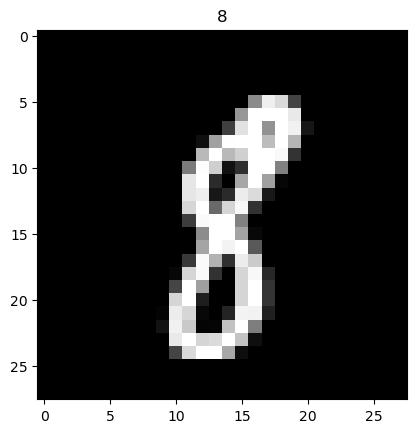

In [80]:
plt.imshow(sample.reshape(28,28),cmap='gray')
plt.title(y_train[300])
plt.show()

In [81]:
def init_params():
    W1 = np.random.rand(25, 784) - 0.5  # Weights for hidden layer  784,60000
    b1 = np.random.rand(25, 1) - 0.5    # Biases for hidden layer
    
    W2 = np.random.rand(15, 25) - 0.5   # Weights for hidden layer 2 15,60000
    b2 = np.random.rand(15, 1) - 0.5    # Biases for hidden layer 2
    
    W3 = np.random.rand(10, 15) - 0.5   # Weights for output layer 10,60000
    b3 = np.random.rand(10, 1) - 0.5    # Biases for output layer
    
    return W1, b1, W2, b2, W3, b3

In [82]:
def ReLu(z):
    return np.maximum(0,z)


In [126]:
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))  # stability
    return expZ / np.sum(expZ, axis=0, keepdims=True)

In [112]:
def forward_prop(W1, b1, W2, b2, W3, b3, X):
    Z1 = W1.dot(X) + b1       # Linear transformation for hidden layer
    A1 = ReLu(Z1)             # Apply ReLU activation
    
    Z2 = W2.dot(A1) + b2      # Linear transformation for output layer
    A2 = ReLu(Z2)          # Apply softmax activation for output layer

    Z3 = W3.dot(A2) + b3
    A3 = softmax(Z3)
    
    return Z1, A1, Z2, A2, Z3, A3

In [113]:
def one_hot(Y): 
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1 
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

In [114]:
print(one_hot(y_train)[:,0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [131]:
def ReLU_deriv(z):
    return z>0

In [134]:
def backward_prop(Z1,A1,Z2,A2,Z3,A3,W1,W2,W3,x_train,y_train):
    m = x_train.shape[1]
    one_hot_Y = one_hot(y_train)
    dZ3 = A3 - one_hot_Y
    dW3 = 1 / m * dZ3.dot(A2.T)
    db3 = 1 / m * np.sum(dZ3,axis=1, keepdims=True)
    
    dZ2 = W3.T.dot(dZ3) * ReLU_deriv(Z2)
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(x_train.T)
    db1 = 1 / m * np.sum(dZ1,axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2, dW3,db3

In [140]:
def update_params(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    W3 = W3 - alpha * dW3
    b3 = b3 - alpha * db3
    return W1, b1, W2, b2, W3, b3

In [118]:
def get_predictions(A3):
    return np.argmax(A3,axis=0)

In [142]:
def get_accuracy(predictions, Y):
    
    return np.sum(predictions == Y) / Y.size

In [145]:
def gradient_descent(x_train,y_train,alpha,iterations):
    W1,b1,W2,b2,W3,b3 = init_params()

    for i in range(iterations):
        Z1,A1,Z2,A2,Z3,A3 = forward_prop(W1,b1,W2,b2,W3,b3,x_train)
        dW1, db1, dW2, db2, dW3, db3 = backward_prop(Z1, A1, Z2, A2,Z3,A3, W1, W2,W3, x_train, y_train)
        W1, b1, W2, b2, W3, b3 = update_params(W1, b1, W2, b2,W3,b3, dW1, db1, dW2, db2,dW3,db3 ,alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions  = get_predictions(A3)
            print(get_accuracy(predictions, y_train))
    return W1, b1, W2, b2, W3, b3
        

In [146]:
W1, b1, W2, b2, W3, b3 = gradient_descent(x_train, y_train, 0.10, 500)

Iteration:  0
0.11233333333333333
Iteration:  10
0.26705
Iteration:  20
0.4013333333333333
Iteration:  30
0.48985
Iteration:  40
0.5605333333333333
Iteration:  50
0.61755
Iteration:  60
0.6572833333333333
Iteration:  70
0.6853166666666667
Iteration:  80
0.7049166666666666
Iteration:  90
0.72215
Iteration:  100
0.7358
Iteration:  110
0.7478833333333333
Iteration:  120
0.7589333333333333
Iteration:  130
0.7681333333333333
Iteration:  140
0.77595
Iteration:  150
0.7835166666666666
Iteration:  160
0.7903833333333333
Iteration:  170
0.797
Iteration:  180
0.8025166666666667
Iteration:  190
0.8072166666666667
Iteration:  200
0.8123666666666667
Iteration:  210
0.8169333333333333
Iteration:  220
0.8208333333333333
Iteration:  230
0.82485
Iteration:  240
0.8281833333333334
Iteration:  250
0.8314833333333334
Iteration:  260
0.8346166666666667
Iteration:  270
0.8373
Iteration:  280
0.8405333333333334
Iteration:  290
0.84315
Iteration:  300
0.846
Iteration:  310
0.84805
Iteration:  320
0.8504
Itera

In [159]:
def make_predictions(X, W1, b1, W2, b2,W3,b3):
    _,_,_, _, _, A2 = forward_prop(W1, b1, W2, b2,W3,b3, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2,W3,b3):
    current_image = x_train[:, index, None]
    prediction = make_predictions(x_train[:, index, None], W1, b1, W2, b2,W3,b3)
    label = y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [5]
Label:  5


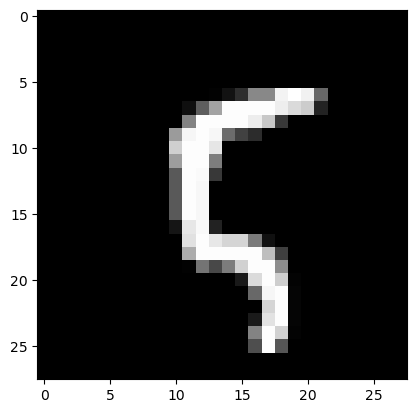

Prediction:  [1]
Label:  1


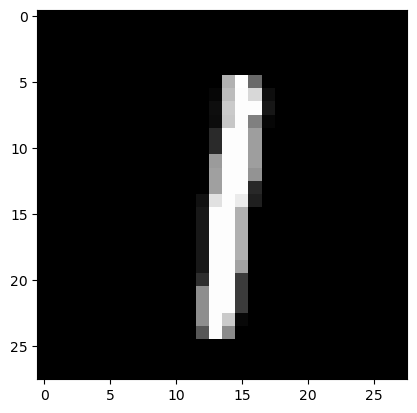

Prediction:  [0]
Label:  0


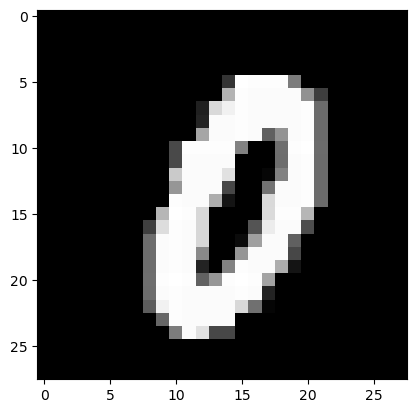

Prediction:  [3]
Label:  3


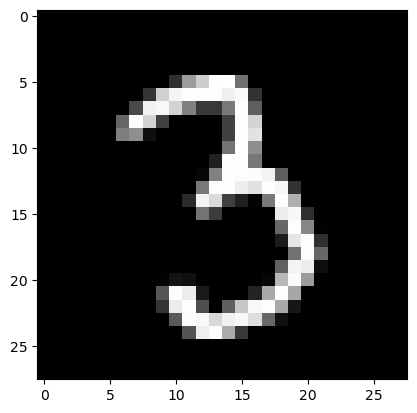

In [163]:
test_prediction(100, W1, b1, W2, b2,W3,b3)
test_prediction(40, W1, b1, W2, b2,W3,b3)
test_prediction(34, W1, b1, W2, b2,W3,b3)
test_prediction(30000, W1, b1, W2, b2,W3,b3)